<a href="https://colab.research.google.com/github/minahss/covid-cxr-ai-medicine/blob/main/03_resnet18_twostage_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Radiography Project — ResNet18 Two-Stage Final Version

This notebook is the recommended final ResNet18 version.

Main idea:
- Stage 1: freeze the ResNet18 pretrained backbone and train only the new classifier head.
- Stage 2: unfreeze the last ResNet18 block and fine-tune with a smaller learning rate.
- Final evaluation is done once on the untouched test set.

This makes the comparison with the two-stage MobileNetV2 version more controlled.

Leakage prevention:
- Exact duplicate files are removed using SHA-256 before splitting.
- Train/validation/test split is stratified.
- Class weights are computed only from the training set.
- Data augmentation is applied only to training images.
- The test set is not used for model selection.


In [1]:
!pip -q install kagglehub torch torchvision scikit-learn

import os
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

RANDOM_STATE = 42
IMG_SIZE = 224
BATCH_SIZE = 32

STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 30

STAGE1_PATIENCE = 3
STAGE2_PATIENCE = 5

STAGE1_LR = 1e-3
STAGE2_LR = 1e-5

STAGE1_MODEL_PATH = "resnet18_stage1_best_validation.pt"
FINAL_MODEL_PATH = "resnet18_twostage_best_validation.pt"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cu128
Device: cuda


## 1. Load dataset and remove exact duplicates

In [2]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))

possible_root = dataset_path / "COVID-19_Radiography_Dataset"
data_root = possible_root if possible_root.exists() else dataset_path

class_names = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

records = []

for class_name in class_names:
    class_dir = data_root / class_name
    image_dir = class_dir / "images"
    if not image_dir.exists():
        image_dir = class_dir

    image_paths = []
    for ext in ["*.png", "*.jpg", "*.jpeg"]:
        image_paths.extend(image_dir.glob(ext))

    for path in image_paths:
        records.append({"path": str(path), "label": class_name})

df = pd.DataFrame(records)

# SHA-256 detects exact duplicate files.
# Exact duplicates are removed before splitting to reduce leakage risk.
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

df["sha256"] = df["path"].apply(sha256_file)
n_duplicates = df["sha256"].duplicated().sum()

df_clean = df.drop_duplicates(subset="sha256", keep="first").reset_index(drop=True)

print("Original images:", len(df))
print("Exact duplicates removed:", n_duplicates)
print("Images after duplicate removal:", len(df_clean))

display(df_clean["label"].value_counts().loc[class_names])

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Original images: 21165
Exact duplicates removed: 54
Images after duplicate removal: 21111


,count
label,
COVID,3570
Lung_Opacity,6012
Normal,10191
Viral Pneumonia,1338


## 2. Basic image checks

In [3]:
sizes = []
modes = []

for path in df_clean["path"].values:
    with Image.open(path) as img:
        sizes.append(img.size)
        modes.append(img.mode)

print("Image sizes:")
display(pd.Series(sizes).value_counts().head())

print("Image modes:")
display(pd.Series(modes).value_counts())

Image sizes:


,count
"(299, 299)",21111


Image modes:


,count
L,20971
RGB,140


## 3. Stratified train/validation/test split

In [4]:
# The split is stratified by class.
# The test set is kept untouched until final evaluation.

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_clean["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts()
}).loc[class_names]

display(split_counts)

# Save split files for reproducibility.
train_df.to_csv("split_train.csv", index=False)
val_df.to_csv("split_val.csv", index=False)
test_df.to_csv("split_test.csv", index=False)

print("Saved split_train.csv, split_val.csv, split_test.csv")

Train: (14777, 3)
Validation: (3167, 3)
Test: (3167, 3)


,train,validation,test
label,,,
COVID,2499,536,535
Lung_Opacity,4208,902,902
Normal,7133,1529,1529
Viral Pneumonia,937,200,201


Saved split_train.csv, split_val.csv, split_test.csv


## 4. Label encoding

In [5]:
label_to_id = {name: i for i, name in enumerate(class_names)}
id_to_label = {i: name for name, i in label_to_id.items()}

for split_df in [train_df, val_df, test_df]:
    split_df["label_id"] = split_df["label"].map(label_to_id)

print(label_to_id)

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


## 5. PyTorch dataset and preprocessing

In [6]:
# ResNet18 was pretrained on ImageNet.
# Therefore, images are normalized using ImageNet mean and standard deviation.
# Data augmentation is applied only to the training set.

weights = ResNet18_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.90, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

class CXRDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = int(row["label_id"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

train_dataset = CXRDataset(train_df, transform=train_transform)
val_dataset = CXRDataset(val_df, transform=eval_transform)
test_dataset = CXRDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


## 6. Majority baseline

In [7]:
# Baseline: always predict the most frequent training class.
# This gives a reference floor for the CNN results.

test_true_for_baseline = test_df["label_id"].values
majority_class = train_df["label_id"].mode()[0]
baseline_pred = np.full_like(test_true_for_baseline, fill_value=majority_class)

baseline_metrics = pd.DataFrame([{
    "Model": "Majority baseline",
    "Majority class": id_to_label[majority_class],
    "Accuracy": accuracy_score(test_true_for_baseline, baseline_pred),
    "Balanced accuracy": balanced_accuracy_score(test_true_for_baseline, baseline_pred)
}])

display(baseline_metrics.round(4))

print(classification_report(
    test_true_for_baseline,
    baseline_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

,Model,Majority class,Accuracy,Balanced accuracy
0,Majority baseline,Normal,0.4828,0.25


                 precision    recall  f1-score   support

          COVID     0.0000    0.0000    0.0000       535
   Lung_Opacity     0.0000    0.0000    0.0000       902
         Normal     0.4828    1.0000    0.6512      1529
Viral Pneumonia     0.0000    0.0000    0.0000       201

       accuracy                         0.4828      3167
      macro avg     0.1207    0.2500    0.1628      3167
   weighted avg     0.2331    0.4828    0.3144      3167



## 7. Class weights

In [8]:
# Class weights are computed only from the training set.
# They are used in CrossEntropyLoss to reduce the effect of class imbalance.

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array(range(len(class_names))),
    y=train_df["label_id"].values
)

class_weights_tensor = torch.tensor(class_weights_values, dtype=torch.float32).to(device)

for i, weight in enumerate(class_weights_values):
    print(id_to_label[i], ":", round(float(weight), 3))

COVID : 1.478
Lung_Opacity : 0.878
Normal : 0.518
Viral Pneumonia : 3.943


## 8. Build ResNet18 model

In [9]:
# ResNet18 pretrained on ImageNet.
# The final fully connected layer is replaced with a 4-class classifier.

model = models.resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(model.fc)
print("Total parameters:", sum(p.numel() for p in model.parameters()))
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


Linear(in_features=512, out_features=4, bias=True)
Total parameters: 11178564
Trainable parameters: 11178564


## 9. Training and validation functions

In [10]:
def run_one_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_true = []
    all_pred = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * images.size(0)
        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_true, all_pred)
    bal_acc = balanced_accuracy_score(all_true, all_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_true,
        all_pred,
        average="macro",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "true": all_true,
        "pred": all_pred,
        "probs": all_probs
    }

def set_trainable_backbone(model, trainable=False):
    # Freeze or unfreeze all layers except the final classifier.
    for name, param in model.named_parameters():
        if name.startswith("fc."):
            param.requires_grad = True
        else:
            param.requires_grad = trainable

def set_stage2_finetuning(model):
    # Fine-tune only the final ResNet block and classifier.
    # This is more comparable to fine-tuning the last layers of MobileNetV2.
    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 10. Stage 1 — Frozen ResNet18 backbone

In [11]:
# Stage 1: freeze the pretrained backbone and train only the final classifier.

set_trainable_backbone(model, trainable=False)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR
)

print("Trainable parameters in Stage 1:", count_trainable_parameters(model))

history_stage1 = []
best_val_loss = np.inf
epochs_without_improvement = 0

for epoch in range(1, STAGE1_EPOCHS + 1):
    train_result = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_result = run_one_epoch(model, val_loader, optimizer=None)

    row = {
        "stage": "stage1_frozen",
        "epoch_in_stage": epoch,
        "train_loss": train_result["loss"],
        "train_accuracy": train_result["accuracy"],
        "train_balanced_accuracy": train_result["balanced_accuracy"],
        "train_macro_f1": train_result["macro_f1"],
        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"],
        "val_balanced_accuracy": val_result["balanced_accuracy"],
        "val_macro_f1": val_result["macro_f1"],
    }
    history_stage1.append(row)

    print(
        f"Stage 1 Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f}, train_macro_f1={row['train_macro_f1']:.4f} | "
        f"val_loss={row['val_loss']:.4f}, val_macro_f1={row['val_macro_f1']:.4f}, "
        f"val_bal_acc={row['val_balanced_accuracy']:.4f}"
    )

    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), STAGE1_MODEL_PATH)
        print("  Saved best Stage 1 validation model.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= STAGE1_PATIENCE:
        print("Stage 1 early stopping triggered.")
        break

# Load best Stage 1 checkpoint before fine-tuning.
model.load_state_dict(torch.load(STAGE1_MODEL_PATH, map_location=device))
print("Loaded best Stage 1 model.")

Trainable parameters in Stage 1: 2052
Stage 1 Epoch 01 | train_loss=0.7194, train_macro_f1=0.6706 | val_loss=0.5434, val_macro_f1=0.7418, val_bal_acc=0.7931
  Saved best Stage 1 validation model.
Stage 1 Epoch 02 | train_loss=0.5475, train_macro_f1=0.7497 | val_loss=0.5095, val_macro_f1=0.7945, val_bal_acc=0.8093
  Saved best Stage 1 validation model.
Stage 1 Epoch 03 | train_loss=0.5045, train_macro_f1=0.7682 | val_loss=0.4803, val_macro_f1=0.8030, val_bal_acc=0.8172
  Saved best Stage 1 validation model.
Stage 1 Epoch 04 | train_loss=0.4914, train_macro_f1=0.7750 | val_loss=0.4717, val_macro_f1=0.7921, val_bal_acc=0.8208
  Saved best Stage 1 validation model.
Stage 1 Epoch 05 | train_loss=0.4715, train_macro_f1=0.7816 | val_loss=0.4630, val_macro_f1=0.8024, val_bal_acc=0.8293
  Saved best Stage 1 validation model.
Stage 1 Epoch 06 | train_loss=0.4633, train_macro_f1=0.7884 | val_loss=0.4435, val_macro_f1=0.8153, val_bal_acc=0.8361
  Saved best Stage 1 validation model.
Stage 1 Epoch 

## 11. Stage 2 — Fine-tune last ResNet18 block

In [12]:
# Stage 2: fine-tune the final residual block (layer4) and classifier with a smaller learning rate.

set_stage2_finetuning(model)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE2_LR
)

print("Trainable parameters in Stage 2:", count_trainable_parameters(model))

history_stage2 = []
best_val_loss = np.inf
epochs_without_improvement = 0

for epoch in range(1, STAGE2_EPOCHS + 1):
    train_result = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_result = run_one_epoch(model, val_loader, optimizer=None)

    row = {
        "stage": "stage2_finetune",
        "epoch_in_stage": epoch,
        "train_loss": train_result["loss"],
        "train_accuracy": train_result["accuracy"],
        "train_balanced_accuracy": train_result["balanced_accuracy"],
        "train_macro_f1": train_result["macro_f1"],
        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"],
        "val_balanced_accuracy": val_result["balanced_accuracy"],
        "val_macro_f1": val_result["macro_f1"],
    }
    history_stage2.append(row)

    print(
        f"Stage 2 Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f}, train_macro_f1={row['train_macro_f1']:.4f} | "
        f"val_loss={row['val_loss']:.4f}, val_macro_f1={row['val_macro_f1']:.4f}, "
        f"val_bal_acc={row['val_balanced_accuracy']:.4f}"
    )

    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), FINAL_MODEL_PATH)
        print("  Saved best Stage 2 validation model.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= STAGE2_PATIENCE:
        print("Stage 2 early stopping triggered.")
        break

# Load final best fine-tuned model.
model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
print("Loaded best fine-tuned ResNet18 model.")

Trainable parameters in Stage 2: 8395780
Stage 2 Epoch 01 | train_loss=0.3765, train_macro_f1=0.8258 | val_loss=0.3208, val_macro_f1=0.8645, val_bal_acc=0.8823
  Saved best Stage 2 validation model.
Stage 2 Epoch 02 | train_loss=0.2974, train_macro_f1=0.8642 | val_loss=0.2730, val_macro_f1=0.8890, val_bal_acc=0.8996
  Saved best Stage 2 validation model.
Stage 2 Epoch 03 | train_loss=0.2503, train_macro_f1=0.8901 | val_loss=0.2370, val_macro_f1=0.9029, val_bal_acc=0.9125
  Saved best Stage 2 validation model.
Stage 2 Epoch 04 | train_loss=0.2216, train_macro_f1=0.9060 | val_loss=0.2263, val_macro_f1=0.9053, val_bal_acc=0.9098
  Saved best Stage 2 validation model.
Stage 2 Epoch 05 | train_loss=0.2082, train_macro_f1=0.9094 | val_loss=0.2125, val_macro_f1=0.9067, val_bal_acc=0.9190
  Saved best Stage 2 validation model.
Stage 2 Epoch 06 | train_loss=0.1917, train_macro_f1=0.9143 | val_loss=0.2011, val_macro_f1=0.9199, val_bal_acc=0.9262
  Saved best Stage 2 validation model.
Stage 2 Epo

## 12. Training curves

,stage,epoch_in_stage,train_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,global_epoch
0,stage1_frozen,1,0.719377,0.701834,0.731754,0.670620,0.543438,0.753710,0.793062,0.741832,1
1,stage1_frozen,2,0.547537,0.764228,0.796220,0.749677,0.509503,0.801074,0.809254,0.794472,2
2,stage1_frozen,3,0.504495,0.780064,0.811447,0.768160,0.480295,0.801389,0.817207,0.803048,3
3,stage1_frozen,4,0.491437,0.786357,0.817045,0.774994,0.471664,0.800442,0.820844,0.792103,4
4,stage1_frozen,5,0.471461,0.791636,0.822513,0.781622,0.462992,0.788128,0.829316,0.802367,5
5,stage1_frozen,6,0.463303,0.795967,0.826978,0.788356,0.443472,0.808020,0.836097,0.815270,6
6,stage1_frozen,7,0.472757,0.787508,0.818772,0.780400,0.433135,0.804863,0.837228,0.813593,7
7,stage1_frozen,8,0.467143,0.791027,0.822175,0.784781,0.461927,0.822861,0.830748,0.827557,8
8,stage1_frozen,9,0.456086,0.797794,0.831474,0.793823,0.441813,0.822229,0.841690,0.828272,9
9,stage1_frozen,10,0.455964,0.795425,0.825881,0.788198,0.512260,0.741396,0.798668,0.772580,10


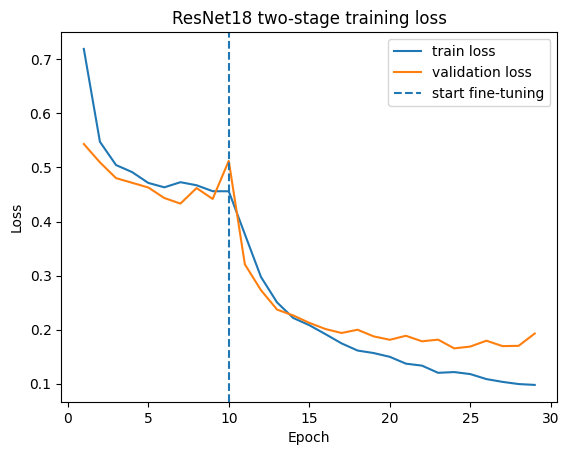

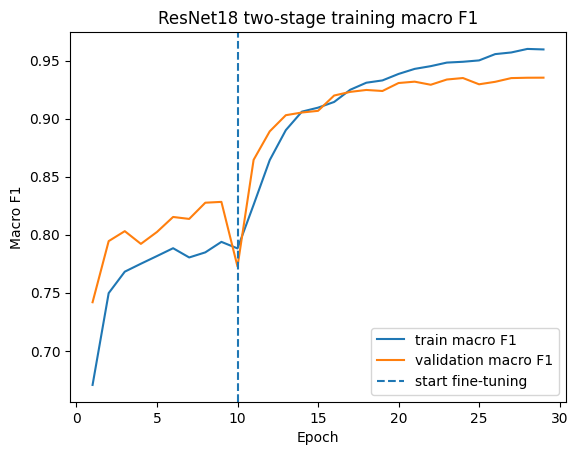

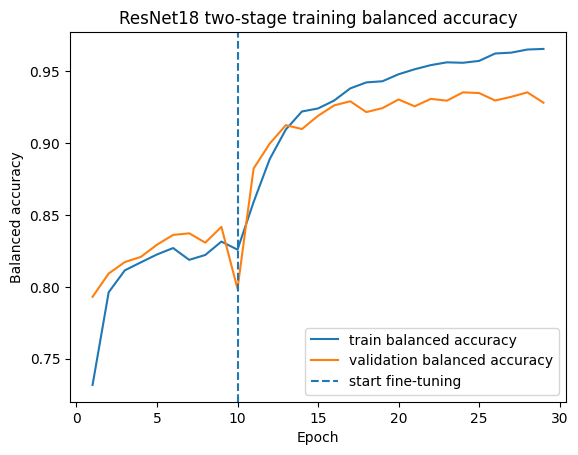

In [13]:
history_df = pd.DataFrame(history_stage1 + history_stage2)
history_df["global_epoch"] = np.arange(1, len(history_df) + 1)

display(history_df)

stage1_length = len(history_stage1)

plt.figure()
plt.plot(history_df["global_epoch"], history_df["train_loss"], label="train loss")
plt.plot(history_df["global_epoch"], history_df["val_loss"], label="validation loss")
plt.axvline(stage1_length, linestyle="--", label="start fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 two-stage training loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_df["global_epoch"], history_df["train_macro_f1"], label="train macro F1")
plt.plot(history_df["global_epoch"], history_df["val_macro_f1"], label="validation macro F1")
plt.axvline(stage1_length, linestyle="--", label="start fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("ResNet18 two-stage training macro F1")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_df["global_epoch"], history_df["train_balanced_accuracy"], label="train balanced accuracy")
plt.plot(history_df["global_epoch"], history_df["val_balanced_accuracy"], label="validation balanced accuracy")
plt.axvline(stage1_length, linestyle="--", label="start fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Balanced accuracy")
plt.title("ResNet18 two-stage training balanced accuracy")
plt.legend()
plt.show()

## 13. Final test evaluation

In [14]:
test_result = run_one_epoch(model, test_loader, optimizer=None)

test_true = test_result["true"]
test_pred = test_result["pred"]
test_probs = test_result["probs"]

test_accuracy = accuracy_score(test_true, test_pred)
test_balanced_accuracy = balanced_accuracy_score(test_true, test_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

resnet18_metrics = pd.DataFrame([{
    "Model": "ResNet18 two-stage",
    "Accuracy": test_accuracy,
    "Balanced accuracy": test_balanced_accuracy,
    "Macro precision": precision_macro,
    "Macro recall": recall_macro,
    "Macro F1": f1_macro,
    "Weighted precision": precision_weighted,
    "Weighted recall": recall_weighted,
    "Weighted F1": f1_weighted
}])

display(resnet18_metrics.round(4))

print(classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

,Model,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1,Weighted precision,Weighted recall,Weighted F1
0,ResNet18 two-stage,0.9252,0.9339,0.9363,0.9339,0.935,0.9256,0.9252,0.9253


                 precision    recall  f1-score   support

          COVID     0.9512    0.9477    0.9494       535
   Lung_Opacity     0.8848    0.9113    0.8979       902
         Normal     0.9344    0.9215    0.9279      1529
Viral Pneumonia     0.9746    0.9552    0.9648       201

       accuracy                         0.9252      3167
      macro avg     0.9363    0.9339    0.9350      3167
   weighted avg     0.9256    0.9252    0.9253      3167



## 14. Confusion matrix

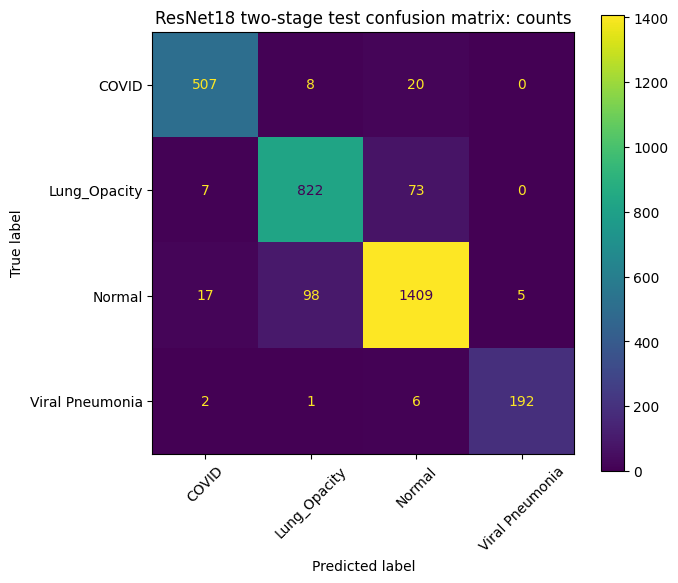

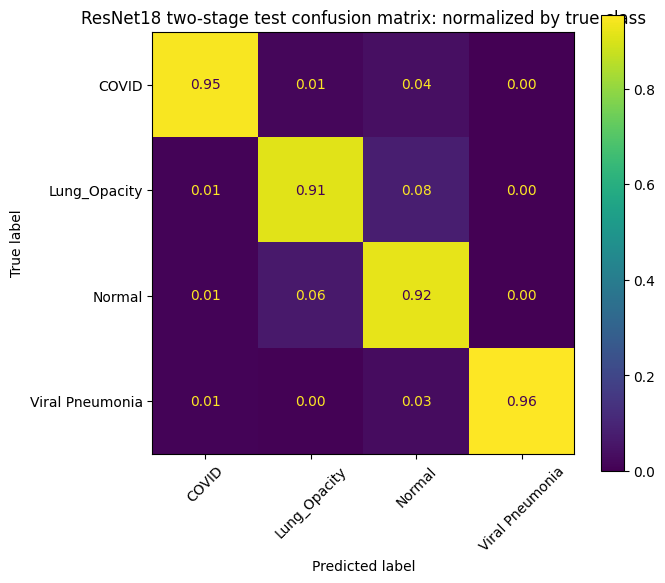

In [15]:
cm = confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ResNet18 two-stage test confusion matrix: counts")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(test_true, test_pred, normalize="true")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp_norm.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("ResNet18 two-stage test confusion matrix: normalized by true class")
plt.tight_layout()
plt.show()

## 15. Sensitivity and specificity

In [16]:
sensitivity_specificity_rows = []

for class_id, class_name in enumerate(class_names):
    y_true_binary = (test_true == class_id).astype(int)
    y_pred_binary = (test_pred == class_id).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    sensitivity_specificity_rows.append({
        "Class": class_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    })

sensitivity_specificity_df = pd.DataFrame(sensitivity_specificity_rows)
display(sensitivity_specificity_df.round(4))

,Class,TP,FP,FN,TN,Sensitivity,Specificity
0,COVID,507,26,28,2606,0.9477,0.9901
1,Lung_Opacity,822,107,80,2158,0.9113,0.9528
2,Normal,1409,99,120,1539,0.9215,0.9396
3,Viral Pneumonia,192,5,9,2961,0.9552,0.9983


## 16. AUROC and AUPRC

In [17]:
y_true_bin = label_binarize(test_true, classes=list(range(len(class_names))))

auroc_rows = []
auprc_rows = []

for class_id, class_name in enumerate(class_names):
    auroc = roc_auc_score(y_true_bin[:, class_id], test_probs[:, class_id])
    auprc = average_precision_score(y_true_bin[:, class_id], test_probs[:, class_id])

    auroc_rows.append({"Class": class_name, "AUROC": auroc})
    auprc_rows.append({"Class": class_name, "AUPRC": auprc})

auroc_macro = roc_auc_score(y_true_bin, test_probs, average="macro", multi_class="ovr")
auroc_weighted = roc_auc_score(y_true_bin, test_probs, average="weighted", multi_class="ovr")
auroc_micro = roc_auc_score(y_true_bin, test_probs, average="micro", multi_class="ovr")

auprc_macro = average_precision_score(y_true_bin, test_probs, average="macro")
auprc_weighted = average_precision_score(y_true_bin, test_probs, average="weighted")
auprc_micro = average_precision_score(y_true_bin, test_probs, average="micro")

auroc_df = pd.DataFrame(auroc_rows)
auprc_df = pd.DataFrame(auprc_rows)

display(auroc_df.round(4))
display(auprc_df.round(4))

summary_auc = pd.DataFrame([{
    "Macro AUROC": auroc_macro,
    "Weighted AUROC": auroc_weighted,
    "Micro AUROC": auroc_micro,
    "Macro AUPRC": auprc_macro,
    "Weighted AUPRC": auprc_weighted,
    "Micro AUPRC": auprc_micro
}])

display(summary_auc.round(4))

,Class,AUROC
0,COVID,0.9959
1,Lung_Opacity,0.9797
2,Normal,0.9776
3,Viral Pneumonia,0.9992


,Class,AUPRC
0,COVID,0.9834
1,Lung_Opacity,0.9612
2,Normal,0.9716
3,Viral Pneumonia,0.9906


,Macro AUROC,Weighted AUROC,Micro AUROC,Macro AUPRC,Weighted AUPRC,Micro AUPRC
0,0.9881,0.9826,0.9906,0.9767,0.9719,0.9736


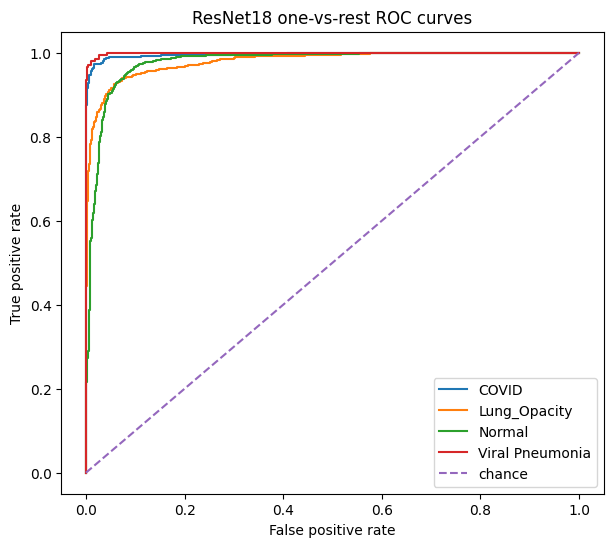

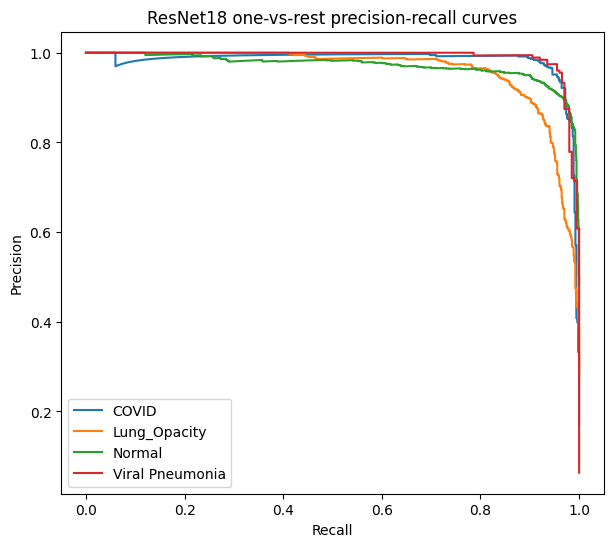

In [18]:
plt.figure(figsize=(7, 6))

for class_id, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, class_id], test_probs[:, class_id])
    plt.plot(fpr, tpr, label=f"{class_name}")

plt.plot([0, 1], [0, 1], linestyle="--", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ResNet18 one-vs-rest ROC curves")
plt.legend()
plt.show()

plt.figure(figsize=(7, 6))

for class_id, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, class_id], test_probs[:, class_id])
    plt.plot(recall, precision, label=f"{class_name}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("ResNet18 one-vs-rest precision-recall curves")
plt.legend()
plt.show()

## 17. High-confidence errors

In [19]:
test_results = test_df[["path", "label", "label_id"]].copy()
test_results["pred_id"] = test_pred
test_results["pred_label"] = [id_to_label[i] for i in test_pred]
test_results["correct"] = test_results["label_id"] == test_results["pred_id"]
test_results["confidence"] = np.max(test_probs, axis=1)

errors = test_results[test_results["correct"] == False].sort_values("confidence", ascending=False)

print("Number of test errors:", len(errors))
display(errors[["label", "pred_label", "confidence", "path"]].head(15))

Number of test errors: 237


,label,pred_label,confidence,path
1557,Normal,COVID,0.999998,/kaggle/input/covid19-radiography-database/COV...
1745,Lung_Opacity,Normal,0.997939,/kaggle/input/covid19-radiography-database/COV...
2454,Normal,Lung_Opacity,0.997060,/kaggle/input/covid19-radiography-database/COV...
3129,Normal,Lung_Opacity,0.996872,/kaggle/input/covid19-radiography-database/COV...
1666,Normal,Lung_Opacity,0.996303,/kaggle/input/covid19-radiography-database/COV...
1353,Normal,Lung_Opacity,0.996066,/kaggle/input/covid19-radiography-database/COV...
2961,Lung_Opacity,Normal,0.995640,/kaggle/input/covid19-radiography-database/COV...
164,Normal,Lung_Opacity,0.995538,/kaggle/input/covid19-radiography-database/COV...
2149,Normal,Lung_Opacity,0.995372,/kaggle/input/covid19-radiography-database/COV...
2294,COVID,Normal,0.994940,/kaggle/input/covid19-radiography-database/COV...


## 18. Save outputs

In [20]:
history_df.to_csv("resnet18_twostage_training_history.csv", index=False)
resnet18_metrics.to_csv("resnet18_twostage_test_summary_metrics.csv", index=False)
sensitivity_specificity_df.to_csv("resnet18_twostage_sensitivity_specificity.csv", index=False)
auroc_df.to_csv("resnet18_twostage_auroc_by_class.csv", index=False)
auprc_df.to_csv("resnet18_twostage_auprc_by_class.csv", index=False)
summary_auc.to_csv("resnet18_twostage_auc_summary.csv", index=False)
test_results.to_csv("resnet18_twostage_test_predictions.csv", index=False)

print("Saved:")
print("- split_train.csv")
print("- split_val.csv")
print("- split_test.csv")
print("- resnet18_stage1_best_validation.pt")
print("- resnet18_twostage_best_validation.pt")
print("- resnet18_twostage_training_history.csv")
print("- resnet18_twostage_test_summary_metrics.csv")
print("- resnet18_twostage_sensitivity_specificity.csv")
print("- resnet18_twostage_auroc_by_class.csv")
print("- resnet18_twostage_auprc_by_class.csv")
print("- resnet18_twostage_auc_summary.csv")
print("- resnet18_twostage_test_predictions.csv")

Saved:
- split_train.csv
- split_val.csv
- split_test.csv
- resnet18_stage1_best_validation.pt
- resnet18_twostage_best_validation.pt
- resnet18_twostage_training_history.csv
- resnet18_twostage_test_summary_metrics.csv
- resnet18_twostage_sensitivity_specificity.csv
- resnet18_twostage_auroc_by_class.csv
- resnet18_twostage_auprc_by_class.csv
- resnet18_twostage_auc_summary.csv
- resnet18_twostage_test_predictions.csv


## Final report notes

Use these points in the report:
- ResNet18 was trained using a two-stage transfer-learning strategy, matching the MobileNetV2 final methodology.
- Stage 1 trained only the final classifier head with the pretrained backbone frozen.
- Stage 2 fine-tuned the final residual block and classifier with a smaller learning rate.
- Exact duplicates were removed using SHA-256 before splitting.
- The test set was used only once after validation-based model selection.
- This comparison is more controlled than training ResNet18 fully from the beginning.
